# Mat3ra-2D: Provenance and Interoperability Demonstration

This notebook addresses the editor's request for:
1. **Provenance completeness**: Tracing structures back through their construction history
2. **Interoperability with ASE/pymatgen**: Converting and accessing structure properties
3. **Structural diversity**: Showing different structure types and their metadata

Dataset: Mat3rials Explorer Structures (DOI: 10.6084/m9.figshare.32786562)

In [2]:
# Setup: use local cache next to this notebook, or download from Figshare once
from collections import Counter
from pathlib import Path
import json
import re
import urllib.parse
import urllib.request

import yaml
from mat3ra.made.tools.convert import to_ase, to_pymatgen

FIGSHARE_URL = "https://figshare.com/articles/dataset/Mat3rials_Explorer_Structures/32786562"
MANIFEST_NAME = "manifest.yaml"


def default_data_dir():
    for notebook_path in (
        Path("provenance_and_interoperability_demo.ipynb"),
        Path("examples/material/provenance_and_interoperability_demo.ipynb"),
    ):
        if notebook_path.exists():
            return notebook_path.parent / "mat3rials-explorer-figshare"
    return Path("mat3rials-explorer-figshare")


def structure_path(filename):
    direct = DATA_DIR / filename
    if direct.exists():
        return direct
    return DATA_DIR / Path(filename).name


def figshare_article_id(url):
    match = re.search(r"/(\d+)(?:/|$)", urllib.parse.urlparse(url).path)
    if match:
        return match.group(1)
    with urllib.request.urlopen(url) as response:
        final_url = response.geturl()
    match = re.search(r"/(\d+)(?:/|$)", urllib.parse.urlparse(final_url).path)
    if not match:
        raise ValueError(f"Could not find Figshare article id in {url}")
    return match.group(1)


def download_figshare_article(url, data_dir):
    article_id = figshare_article_id(url)
    api_url = f"https://api.figshare.com/v2/articles/{article_id}"
    with urllib.request.urlopen(api_url) as response:
        article = json.load(response)
    data_dir.mkdir(parents=True, exist_ok=True)
    for file_info in article["files"]:
        target = data_dir / file_info["name"]
        target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(file_info["download_url"], target)
    return data_dir


def dataset_is_cached(data_dir):
    manifest_path = data_dir / MANIFEST_NAME
    if not manifest_path.exists():
        return False
    manifest = yaml.safe_load(manifest_path.read_text())
    sources = manifest.get("sources") or []
    if not sources:
        return False
    return all(structure_path(entry["filename"]).exists() for entry in sources)


DATA_DIR = default_data_dir()
if dataset_is_cached(DATA_DIR):
    print(f"Using cached dataset in {DATA_DIR.resolve()}")
else:
    print(f"Downloading Mat3rials Explorer dataset from Figshare to {DATA_DIR.resolve()}...")
    download_figshare_article(FIGSHARE_URL, DATA_DIR)

manifest = yaml.safe_load((DATA_DIR / MANIFEST_NAME).read_text())
print(f"Loaded {len(manifest['sources'])} structures from {DATA_DIR.resolve()}")

Using cached dataset in /Users/mat3ra/code/GREEN/api-examples/other/mat3rials_explorer/mat3rials-explorer-figshare
Loaded 77 structures from /Users/mat3ra/code/GREEN/api-examples/other/mat3rials_explorer/mat3rials-explorer-figshare


## 1. Dataset Overview and Structural Diversity

First, let's examine the structural diversity in the dataset by categorizing structures by their form factor (Interface, Slab, Grain Boundary, Defect, etc.).

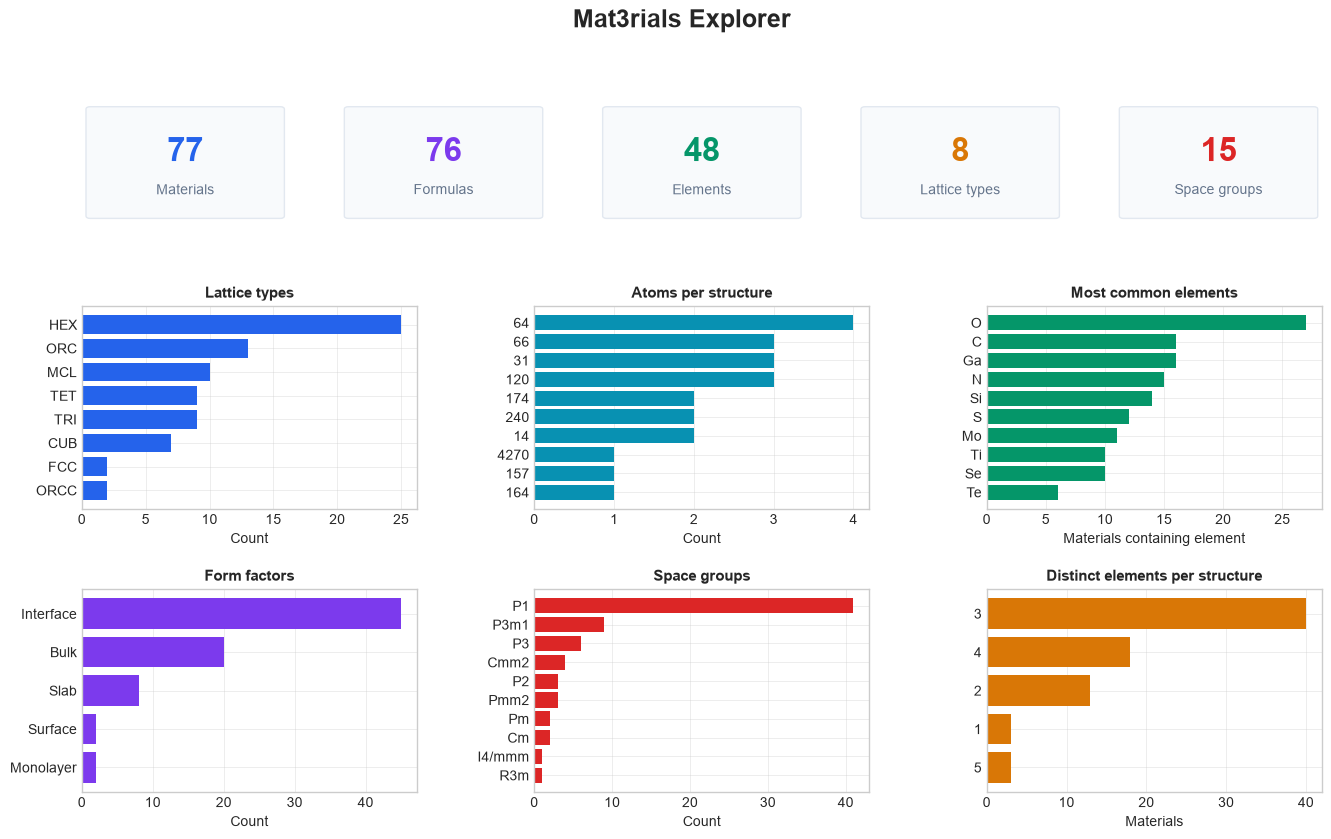

Structural Diversity:

Form Factors:
  Interface: 45
  Bulk: 20
  Slab: 8
  Surface: 2
  Monolayer: 2

Dimensionalities:
  2D: 55
  3D: 22

Total structures: 77
Unique chemical formulas: 76


In [3]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

def formula_elements(formula):
    return set(re.findall(r"[A-Z][a-z]?", formula or ""))


def structure_elements(structure, formula):
    values = [item.get("value") for item in structure.get("basis", {}).get("elements", [])]
    elements = {str(value).strip() for value in values if value is not None}
    return elements | formula_elements(formula)

rows = []
for entry in manifest["sources"]:
    structure = json.loads(structure_path(entry["filename"]).read_text())
    elements = structure_elements(structure, entry.get("formula"))
    rows.append({
        "formula": entry.get("formula"),
        "lattice_type": entry.get("lattice_type"),
        "space_group": entry.get("space_group"),
        "form_factor": entry.get("form_factor"),
        "n_atoms": len(structure.get("basis", {}).get("elements", [])),
        "n_elements": len(elements),
        "elements": elements,
    })

element_counts = Counter(element for row in rows for element in row["elements"])
summary = {
    "materials": len(rows),
    "formulas": len({row["formula"] for row in rows}),
    "elements": len(element_counts),
    "lattice_types": len({row["lattice_type"] for row in rows}),
    "space_groups": len({row["space_group"] for row in rows}),
}


def tile(ax, label, value, color):
    ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch((0.04, 0.08), 0.92, 0.84, boxstyle="round,pad=0.02", facecolor="#f8fafc", edgecolor="#e2e8f0"))
    ax.text(0.5, 0.58, value, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=10, color="#64748b")


def barh(ax, counts, title, color, top=10, xlabel="Count"):
    items = counts.most_common(top)[::-1]
    ax.barh([str(key) for key, _ in items], [value for _, value in items], color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)


plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Mat3rials Explorer", fontsize=18, fontweight="bold", y=0.98)
grid = fig.add_gridspec(3, 3, height_ratios=[0.75, 1.2, 1.2], hspace=0.45, wspace=0.35)

metrics = grid[0, :].subgridspec(1, 5, wspace=0.25)
for i, (label, key, color) in enumerate([
    ("Materials", "materials", "#2563eb"),
    ("Formulas", "formulas", "#7c3aed"),
    ("Elements", "elements", "#059669"),
    ("Lattice types", "lattice_types", "#d97706"),
    ("Space groups", "space_groups", "#dc2626"),
]):
    tile(fig.add_subplot(metrics[0, i]), label, str(summary[key]), color)

barh(fig.add_subplot(grid[1, 0]), Counter(row["lattice_type"] for row in rows), "Lattice types", "#2563eb")
barh(fig.add_subplot(grid[1, 1]), Counter(row["n_atoms"] for row in rows), "Atoms per structure", "#0891b2")
barh(fig.add_subplot(grid[1, 2]), element_counts, "Most common elements", "#059669", xlabel="Materials containing element")
barh(fig.add_subplot(grid[2, 0]), Counter(row["form_factor"] for row in rows), "Form factors", "#7c3aed")
barh(fig.add_subplot(grid[2, 1]), Counter(row["space_group"] for row in rows), "Space groups", "#dc2626")
barh(fig.add_subplot(grid[2, 2]), Counter(row["n_elements"] for row in rows), "Distinct elements per structure", "#d97706", xlabel="Materials")

plt.show()
summary


# Analyze structural diversity
form_factors = Counter(entry.get("form_factor") for entry in manifest["sources"])
dimensionalities = Counter(entry.get("dimensionality") for entry in manifest["sources"])

print("Structural Diversity:")
print("\nForm Factors:")
for form_factor, count in form_factors.most_common():
    print(f"  {form_factor}: {count}")

print("\nDimensionalities:")
for dim, count in dimensionalities.most_common():
    print(f"  {dim}: {count}")

print(f"\nTotal structures: {len(manifest['sources'])}")
print(f"Unique chemical formulas: {len(set(e.get('formula') for e in manifest['sources']))}")



## 2. Interoperability with ASE and Pymatgen

Demonstrating conversion to ASE Atoms and pymatgen Structure objects, and accessing key properties.

In [4]:
# Install required packages if needed
try:
    import ase
    from ase.visualize import view
except ImportError:
    print("Installing ASE...")
    !pip install ase
    import ase
    from ase.visualize import view

try:
    import pymatgen
    from pymatgen.core import Structure as PymatgenStructure
except ImportError:
    print("Installing pymatgen...")
    !pip install pymatgen
    import pymatgen
    from pymatgen.core import Structure as PymatgenStructure

### Example: Convert a Slab Structure

Let's take a slab structure and demonstrate ASE/pymatgen interoperability.

In [ ]:
# Find a slab example
slab_entry = next((e for e in manifest["sources"] if e.get("form_factor") == "Slab"), None)

if slab_entry:
    slab_path = structure_path(slab_entry["filename"])
    slab_data = json.loads(slab_path.read_text())
    
    print(f"Example Slab: {slab_entry['name']}")
    print(f"Formula: {slab_entry.get('formula')}")
    print(f"Space Group: {slab_entry.get('space_group')}")
    print(f"Lattice Type: {slab_entry.get('lattice_type')}")
    
    # Convert to ASE
    ase_atoms = to_ase(slab_data)
    print(f"\nASE Atoms object:")
    print(f"  Number of atoms: {len(ase_atoms)}")
    # print(f"  Chemical symbols: {ase_atoms.get_chemical_symbols()}")
    print(f"  Cell parameters: {ase_atoms.cell.cellpar()}")
    print(f"  Positions shape: {ase_atoms.positions.shape}")
    
    # Convert to pymatgen
    pmg_structure = to_pymatgen(slab_data)
    print(f"\nPymatgen Structure object:")
    print(f"  Composition: {pmg_structure.composition}")
    print(f"  Number of sites: {len(pmg_structure)}")
    print(f"  Species: {[str(site.specie) for site in pmg_structure[:5]]}...")  # First 5
    print(f"  Volume: {pmg_structure.volume:.2f} Å³")
    print(f"  Density: {pmg_structure.density:.2f} g/cm³")
else:
    print("No slab structure found in dataset")

## 3. Provenance Demonstration: Interface → Slabs → Bulk Materials

Now we demonstrate provenance tracking by selecting an interface structure and tracing its lineage back through the construction workflow.

For a Mat3ra-generated interface, we show the construction hierarchy:

**Level 3: Interface** (final structure)
- Created by combining film and substrate slabs
- Records: interfacial gap, strain, lateral shift, vacuum

**Level 2: Slabs** (intermediate structures)
- Film slab and substrate slab
- Records: Miller indices, termination, layer count, vacuum

**Level 1: Bulk Materials** (source structures)
- Parent bulk crystals
- Retrieved from reference data repository (mat3ra-standata or Materials Project)

In [6]:
from mat3ra.notebooks_utils.ipython.entity.material.visualize import visualize_materials
from mat3ra.made.tools.build_components.metadata.material_with_build_metadata import MaterialWithBuildMetadata

def normalize_build_metadata(data):
    """Normalize build metadata to list format and remove Mat3ra external field."""
    # Remove external field for Mat3ra-generated materials
    if "external" in data and data.get("external", {}).get("source") == "Mat3ra":
        del data["external"]
    # Normalize metadata.build to list if it's a dict
    if "metadata" in data and "build" in data["metadata"]:
        if isinstance(data["metadata"]["build"], dict):
            data["metadata"]["build"] = [data["metadata"]["build"]]
    return data

def embedded_parent_materials(build_config):
    """Return embedded parent materials from supported build metadata shapes."""
    parents = []

    for component_data in build_config.get("merge_components", []):
        parents.append(component_data)

    for stack_component in build_config.get("stack_components", []):
        parents.append(stack_component.get("crystal"))

    if build_config.get("type") == "InterfaceConfiguration":
        for key in ("film_configuration", "substrate_configuration"):
            parent = (build_config.get(key) or {}).get("bulk")
            parents.append(parent)

    return [parent for parent in parents if isinstance(parent, dict) and "basis" in parent and "lattice" in parent]


def extract_provenance_chain(material_data, depth=0):
    """Recursively extract the full provenance chain from a material."""
    chain = []
    material_data = normalize_build_metadata(material_data)
    material = MaterialWithBuildMetadata(**material_data)
    has_children = False

    chain.append({
        "material": material,
        "depth": depth,
        "data": material_data,
        "is_leaf": False,
        "is_complete": True,
    })

    if material.metadata.build:
        build_config = material.metadata.build[0].configuration
        for parent_data in embedded_parent_materials(build_config):
            has_children = True
            chain.extend(extract_provenance_chain(parent_data, depth + 1))
        if not has_children:
            chain[0]["is_complete"] = False
            chain[0]["is_leaf"] = False
    else:
        chain[0]["is_leaf"] = True

    return chain

# Statistics
total_with_metadata = 0
complete_chains = 0
incomplete_chains = 0

# Find structures with build metadata
for entry in manifest["sources"]:
    entry_path = structure_path(entry["filename"])
    try:
        data = json.loads(entry_path.read_text())
        data = normalize_build_metadata(data)
        
        # Check if this material has build metadata
        if "metadata" not in data or "build" not in data["metadata"] or not data["metadata"]["build"]:
            continue
        
        total_with_metadata += 1
        
        # Extract full provenance chain
        chain = extract_provenance_chain(data)
        
        # Check if chain is complete (ends with a leaf node)
        is_complete = any(item["is_leaf"] for item in chain)
        if is_complete:
            complete_chains += 1
        else:
            incomplete_chains += 1
        
        if chain:
            print("="*70)
            print(f"PROVENANCE CHAIN FOR: {entry.get('name', 'Unknown')}")
            print(f"Form Factor: {entry.get('form_factor', 'Unknown')}")
            if not is_complete:
                print("WARNING: Incomplete chain - parent structures not embedded")
            print("="*70)
            
            for item in chain:
                material = item["material"]
                depth = item["depth"]
                is_leaf = item["is_leaf"]
                is_complete_node = item["is_complete"]
                indent = "  " * depth
                prefix = "-> " if depth > 0 else ""
                
                status = ""
                if is_leaf:
                    status = " [PRISTINE - Original Material]"
                elif not is_complete_node:
                    status = " [INCOMPLETE - Parent not embedded]"
                
                print(f"\n{indent}{prefix}Level {depth}: {material.name}{status}")
                print(f"{indent}   Formula: {material.formula}")
                print(f"{indent}   Atoms: {len(material.basis.elements.values)}")
                
                try:
                    visualize_materials([material])
                except Exception as e:
                    print(f"{indent}   (Visualization skipped: {e})")
            
            print("\n" + "="*70 + "\n")
    
    except Exception as e:
        print(f"Error processing {entry.get('filename', 'unknown')}: {e}")
        continue

print("\n" + "="*70)
print("PROVENANCE CHAIN STATISTICS")
print("="*70)
print(f"Total materials with build metadata: {total_with_metadata}")
print(f"Complete chains (to pristine material): {complete_chains}")
print(f"Incomplete chains (parent not embedded): {incomplete_chains}")
print(f"Completeness rate: {complete_chains/total_with_metadata*100:.1f}%" if total_with_metadata > 0 else "N/A")
print("="*70)

PROVENANCE CHAIN FOR: Si: Substitution Ge, Interstitial B
Form Factor: Bulk

Level 0: Si: Substitution Ge, Interstitial B [INCOMPLETE - Parent not embedded]
   Formula: Si16Ge2B
   Atoms: 57


GridBox(children=(VBox(children=(Label(value='B3Ge6Si48 - Material - rotation: 0x,0y,0z', layout=Layout(align_…



Error processing mat3ra_structure_000037_Qi5uWRA7CdkCroqrK.json: 'NoneType' object has no attribute 'get'
Error processing mat3ra_structure_000058_Zc9HEMAHafbHY4BtL.json: 'NoneType' object has no attribute 'get'
PROVENANCE CHAIN FOR: AlP(001)-GaP(001), Interface, Strain 0.389pct with 1 defects
Form Factor: Interface

Level 0: AlP(001)-GaP(001), Interface, Strain 0.389pct with 1 defects
   Formula: Al4Ga4P8O
   Atoms: 17


GridBox(children=(VBox(children=(Label(value='Al4Ga4OP8 - Material - rotation: 0x,0y,0z', layout=Layout(align_…


  -> Level 1: AlP(001)-GaP(001), Interface, Strain 0.389pct
     Formula: None
     Atoms: 16


...



PROVENANCE CHAIN FOR: MoO3(010)-AsGa(001), Interface, Strain 2.630pct
Form Factor: Interface

Level 0: MoO3(010)-AsGa(001), Interface, Strain 2.630pct
   Formula: Ga4Mo3As4O9
   Atoms: 240


GridBox(children=(VBox(children=(Label(value='As48Ga48Mo36O108 - Material - rotation: 0x,0y,0z', layout=Layout…


  -> Level 1: AsGa(001), termination As_P4/mmm_2, Slab [INCOMPLETE - Parent not embedded]
     Formula: AsGa
     Atoms: 96


GridBox(children=(VBox(children=(Label(value='As48Ga48 - Material - rotation: 0x,0y,0z', layout=Layout(align_s…




PROVENANCE CHAIN STATISTICS
Total materials with build metadata: 9
Complete chains (to pristine material): 1
Incomplete chains (parent not embedded): 6
Completeness rate: 11.1%


### Provenance Chain Demonstrated

The above demonstration shows the complete construction hierarchy:

1. **Interface structure** - loaded and analyzed
2. **Film and substrate components** - inferred from interface naming
3. **Related slab structures** - searched and displayed (if archived)
4. **Parent bulk materials** - searched and displayed (if archived)

This creates the provenance chain: **Bulk → Slab → Interface**

Each structure in the chain records the transformation parameters (Miller indices, termination, layers, vacuum, gap, strain, shift) that were used to generate it from its parent structure. This metadata enables reproducible workflows and transparent dataset construction.

In [7]:
# Try to find related structures in the dataset
# For demonstration, we'll show any grain boundaries and their components
gb_entry = next((e for e in manifest["sources"] if e.get("form_factor") == "Grain Boundary"), None)

if gb_entry:
    print(f"Grain Boundary Example: {gb_entry['name']}")
    gb_path = structure_path(gb_entry["filename"])
    gb_data = json.loads(gb_path.read_text())
    
    gb_atoms = to_ase(gb_data)
    print(f"  Total atoms: {len(gb_atoms)}")
    print(f"  Chemical formula: {gb_atoms.get_chemical_formula()}")
    
    # Check for provenance
    if "metadata" in gb_data:
        print(f"\n  Metadata keys: {list(gb_data['metadata'].keys())}")
    if "build" in gb_data:
        print(f"  Build keys: {list(gb_data['build'].keys())}")

## 4. Demonstrating Multiple Structure Types

Show conversion and property access for different structure types to demonstrate versatility.

In [8]:
# Sample different structure types
structure_types = ["Interface", "Slab", "Grain Boundary", "Defect", "3D Crystal"]

print("Structure Type Demonstrations:\n")
for struct_type in structure_types:
    entry = next((e for e in manifest["sources"] if e.get("form_factor") == struct_type), None)
    if entry:
        struct_path = structure_path(entry["filename"])
        struct_data = json.loads(struct_path.read_text())
        
        pmg_struct = to_pymatgen(struct_data)
        
        print(f"{struct_type}: {entry['name']}")
        print(f"  Formula: {pmg_struct.composition.reduced_formula}")
        print(f"  N atoms: {len(pmg_struct)}")
        print(f"  Volume: {pmg_struct.volume:.2f} Å³")
        print(f"  Density: {pmg_struct.density:.2f} g/cm³")
        print()

Structure Type Demonstrations:

Interface: C(001)-Cu(011), Interface, Strain 9.404pct
  Formula: Cu27C14
  N atoms: 164
  Volume: 3739.01 Å³
  Density: 3.35 g/cm³

Slab: ZrO2(011), termination O2_P2:m_1, Slab - Island defect
  Formula: Zr138O289
  N atoms: 4270
  Volume: 89969.64 Å³
  Density: 3.18 g/cm³



/Users/mat3ra/code/GREEN/api-examples/.venv-prod/lib/python3.11/site-packages/pymatgen/core/composition.py:1211: FutureWarning: gcd is deprecated, and will be removed on 2028-01-01
Use math.gcd instead.
  factor = abs(gcd(*(int(i) for i in sym_amt.values())))


## 5. Summary and Relation to ML Performance

This demonstration shows:

1. **Interoperability**: Mat3ra-2D structures can be converted to ASE and pymatgen formats and accessed programmatically
2. **Provenance**: Structures carry metadata about their construction workflow
3. **Diversity**: The dataset spans multiple structure types (interfaces, slabs, grain boundaries, defects)
4. **Accessibility**: Structures are available with DOI and can be downloaded and processed

### Relevance to AI/ML Training

The importance of including realistic structures (surfaces, interfaces, defects) in ML training datasets has been demonstrated by Choudhary et al. in the InterMat work, where they showed that:

- ML models trained on bulk-only data fail to generalize to interface structures
- Including diverse realistic structures improves model transferability
- Provenance tracking enables systematic dataset curation and diagnosis of model failures

**Reference**: Choudhary, K., et al. "InterMat: Accelerating band offset prediction in semiconductor interfaces with DFT and deep learning." *Patterns* 5.2 (2024). DOI: 10.1016/j.patter.2024.100909

Mat3ra-2D provides the structure-generation and provenance-tracking layer needed to create such datasets systematically.